In [188]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import confusion_matrix
import glob
import cv2

In [189]:
glioma_train = glob.glob('Brain_tumor/Training/glioma_tumor/*.jpg')
meningioma_train = glob.glob('Brain_tumor/Training/meningioma_tumor/*.jpg')
notumor_train = glob.glob('Brain_tumor/Training/no_tumor/*.jpg')
pituitary_train = glob.glob('Brain_tumor/Training/pituitary_tumor/*.jpg')

In [190]:
# Testing dataset paths

glioma_test = glob.glob('Brain_tumor/Testing/glioma_tumor/*.jpg')
meningioma_test = glob.glob('Brain_tumor/Testing/meningioma_tumor/*.jpg')
notumor_test = glob.glob('Brain_tumor/Testing/no_tumor/*.jpg')
pituitary_test = glob.glob('Brain_tumor/Testing/pituitary_tumor/*.jpg')

In [191]:
print("Number of images in Training set are, Glioma:", len(glioma_train),
      ",Meningioma:", len(meningioma_train),
      ",No Tumor:", len(notumor_train),
      ",Pituitary:", len(pituitary_train))

Number of images in Training set are, Glioma: 84 ,Meningioma: 72 ,No Tumor: 72 ,Pituitary: 84


In [192]:
print("Number of images in Testing set are, Glioma:",len(glioma_test),",Meningioma:",len(meningioma_test),
      ",No Tumor:",len(no_tumor_test),",Pituitory:",len(pituitary_test))

Number of images in Testing set are, Glioma: 24 ,Meningioma: 24 ,No Tumor: 24 ,Pituitory: 24


In [193]:
image_train = []
label_train = []

for i in glioma_train:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_train.append(img)
    label_train.append(0)

for i in meningioma_train:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_train.append(img)
    label_train.append(1)

for i in notumor_train:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_train.append(img)
    label_train.append(2)

for i in pituitary_train:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_train.append(img)
    label_train.append(3)

In [194]:
print(len(image_train))
print(len(label_train))

312
312


In [195]:
image_train = np.array(image_train)
label_train = np.array(label_train)

In [196]:
image_test = []
label_test = []

for i in glioma_test:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_test.append(img)
    label_test.append(0)

for i in meningioma_test:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_test.append(img)
    label_test.append(1)

for i in notumor_test:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_test.append(img)
    label_test.append(2)

for i in pituitary_test:
    img = cv2.imread(i)
    img = cv2.resize(img, (64,64))
    image_test.append(img)
    label_test.append(3)

In [197]:
print(len(image_test))
print(len(label_test))

96
96


In [198]:
image_test = np.array(image_test)
label_test = np.array(label_test)

In [199]:
image_train, label_train = shuffle(image_train,label_train, random_state = 100)

In [200]:
image_train = image_train / 255.0

In [201]:
image_test, label_test = shuffle(image_test,label_test, random_state = 100)

In [202]:
image_test = image_test / 255.0

In [203]:
import cv2

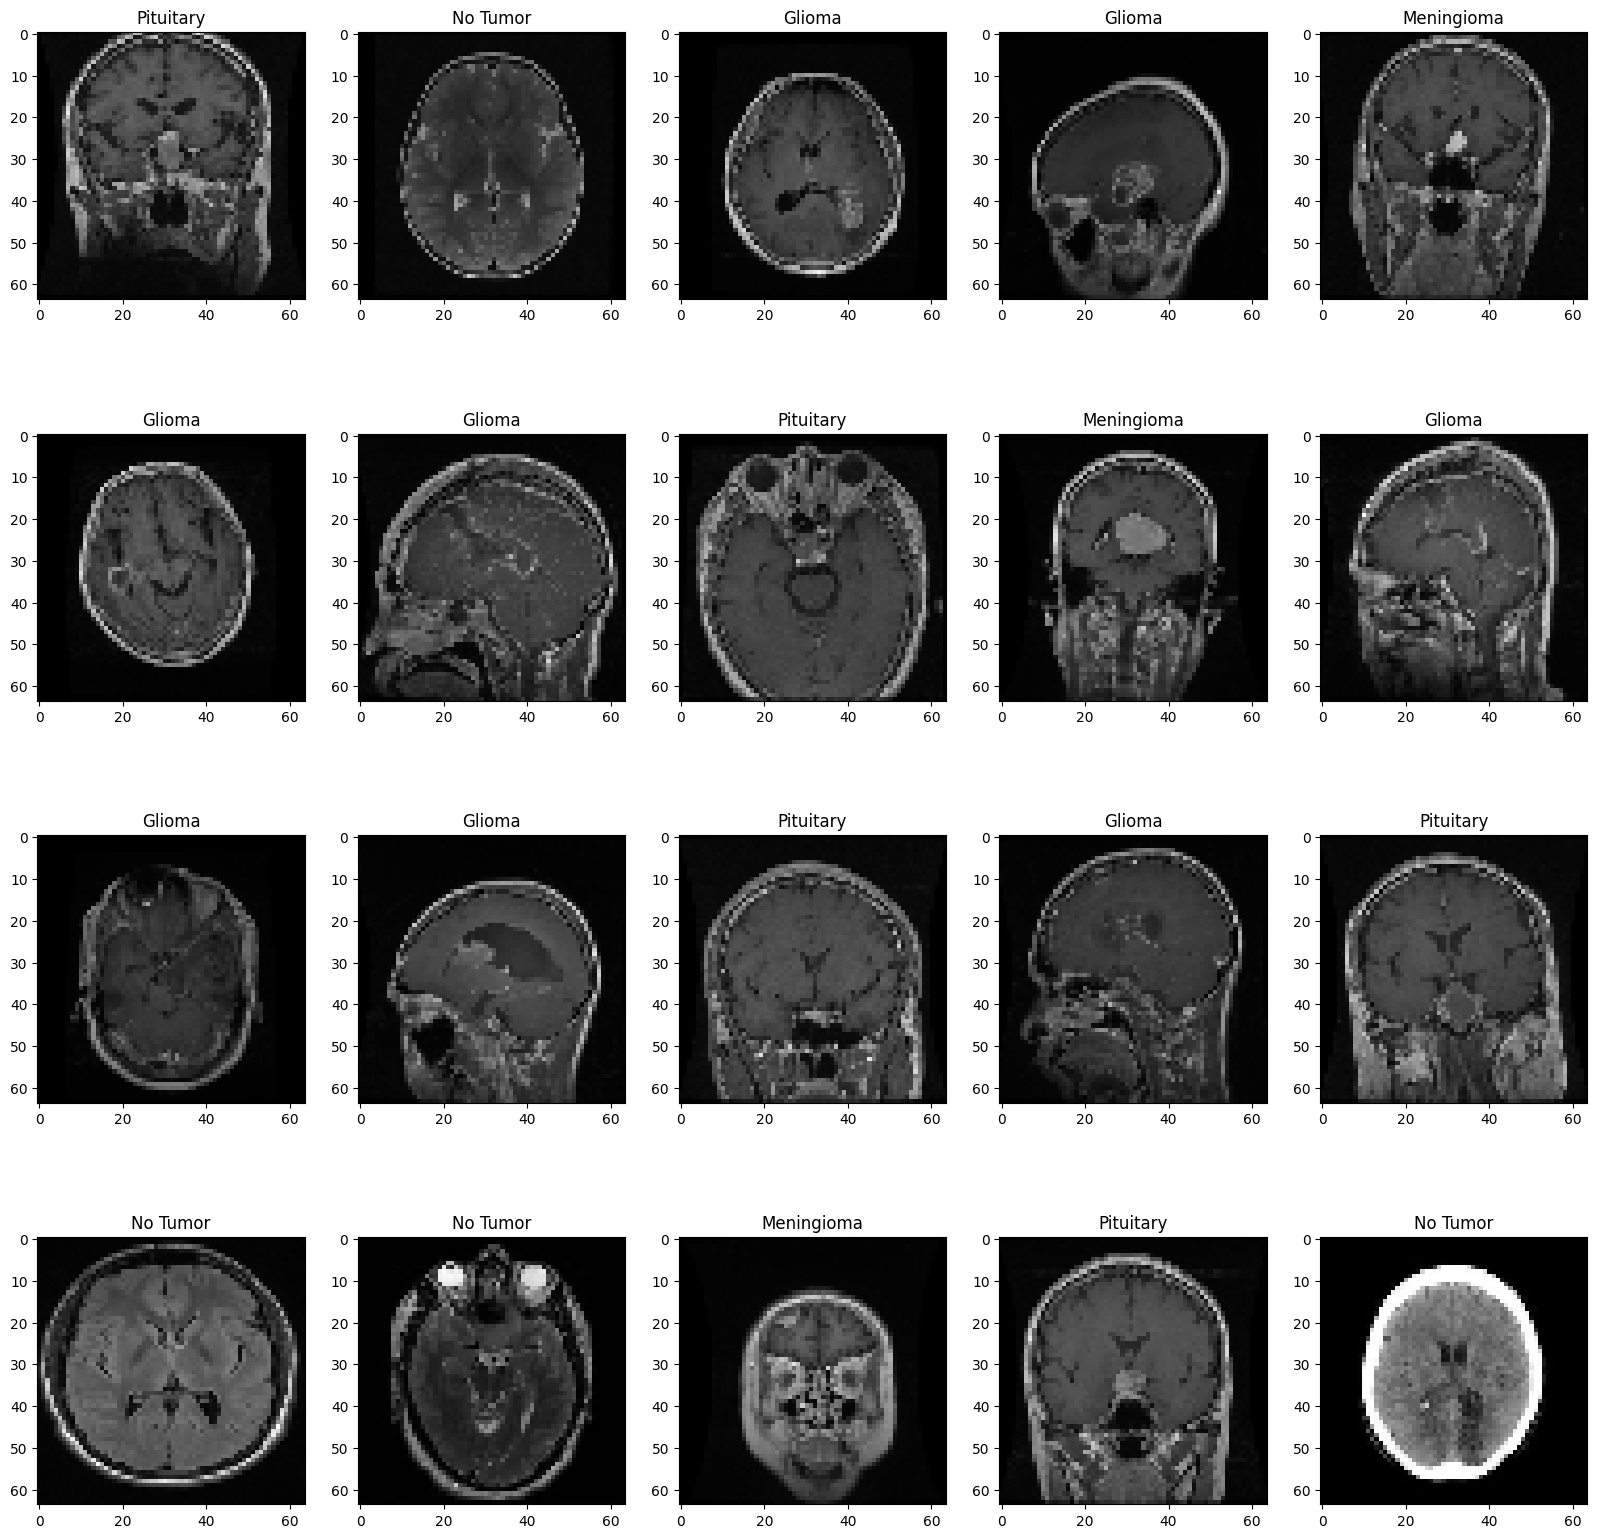

In [204]:
plt.figure(figsize=(20,20))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(image_train[i])
    if label_train[i] == 0:
        plt.title('Glioma')
    elif label_train[i] == 1:
        plt.title('Meningioma')
    elif label_train[i] == 2:
        plt.title('No Tumor')
    else:
        plt.title('Pituitary')
plt.show()

In [205]:
X_train = []

for i in image_train:
    X_train.append(resize(i,(64,64,3)))

X_train = np.array(X_train)

y_train = np.array(label_train)

In [206]:
print(X_train.shape)
print(y_train.shape)

(312, 64, 64, 3)
(312,)


In [207]:
X_test = []

for i in image_test:
    X_test.append(resize(i,(64,64,3)))

X_test = np.array(X_test)

In [208]:
print(len(image_train))

312


In [209]:
print(len(glioma_train))
print(len(meningioma_train))
print(len(notumor_train))
print(len(pituitary_train))

84
72
72
84


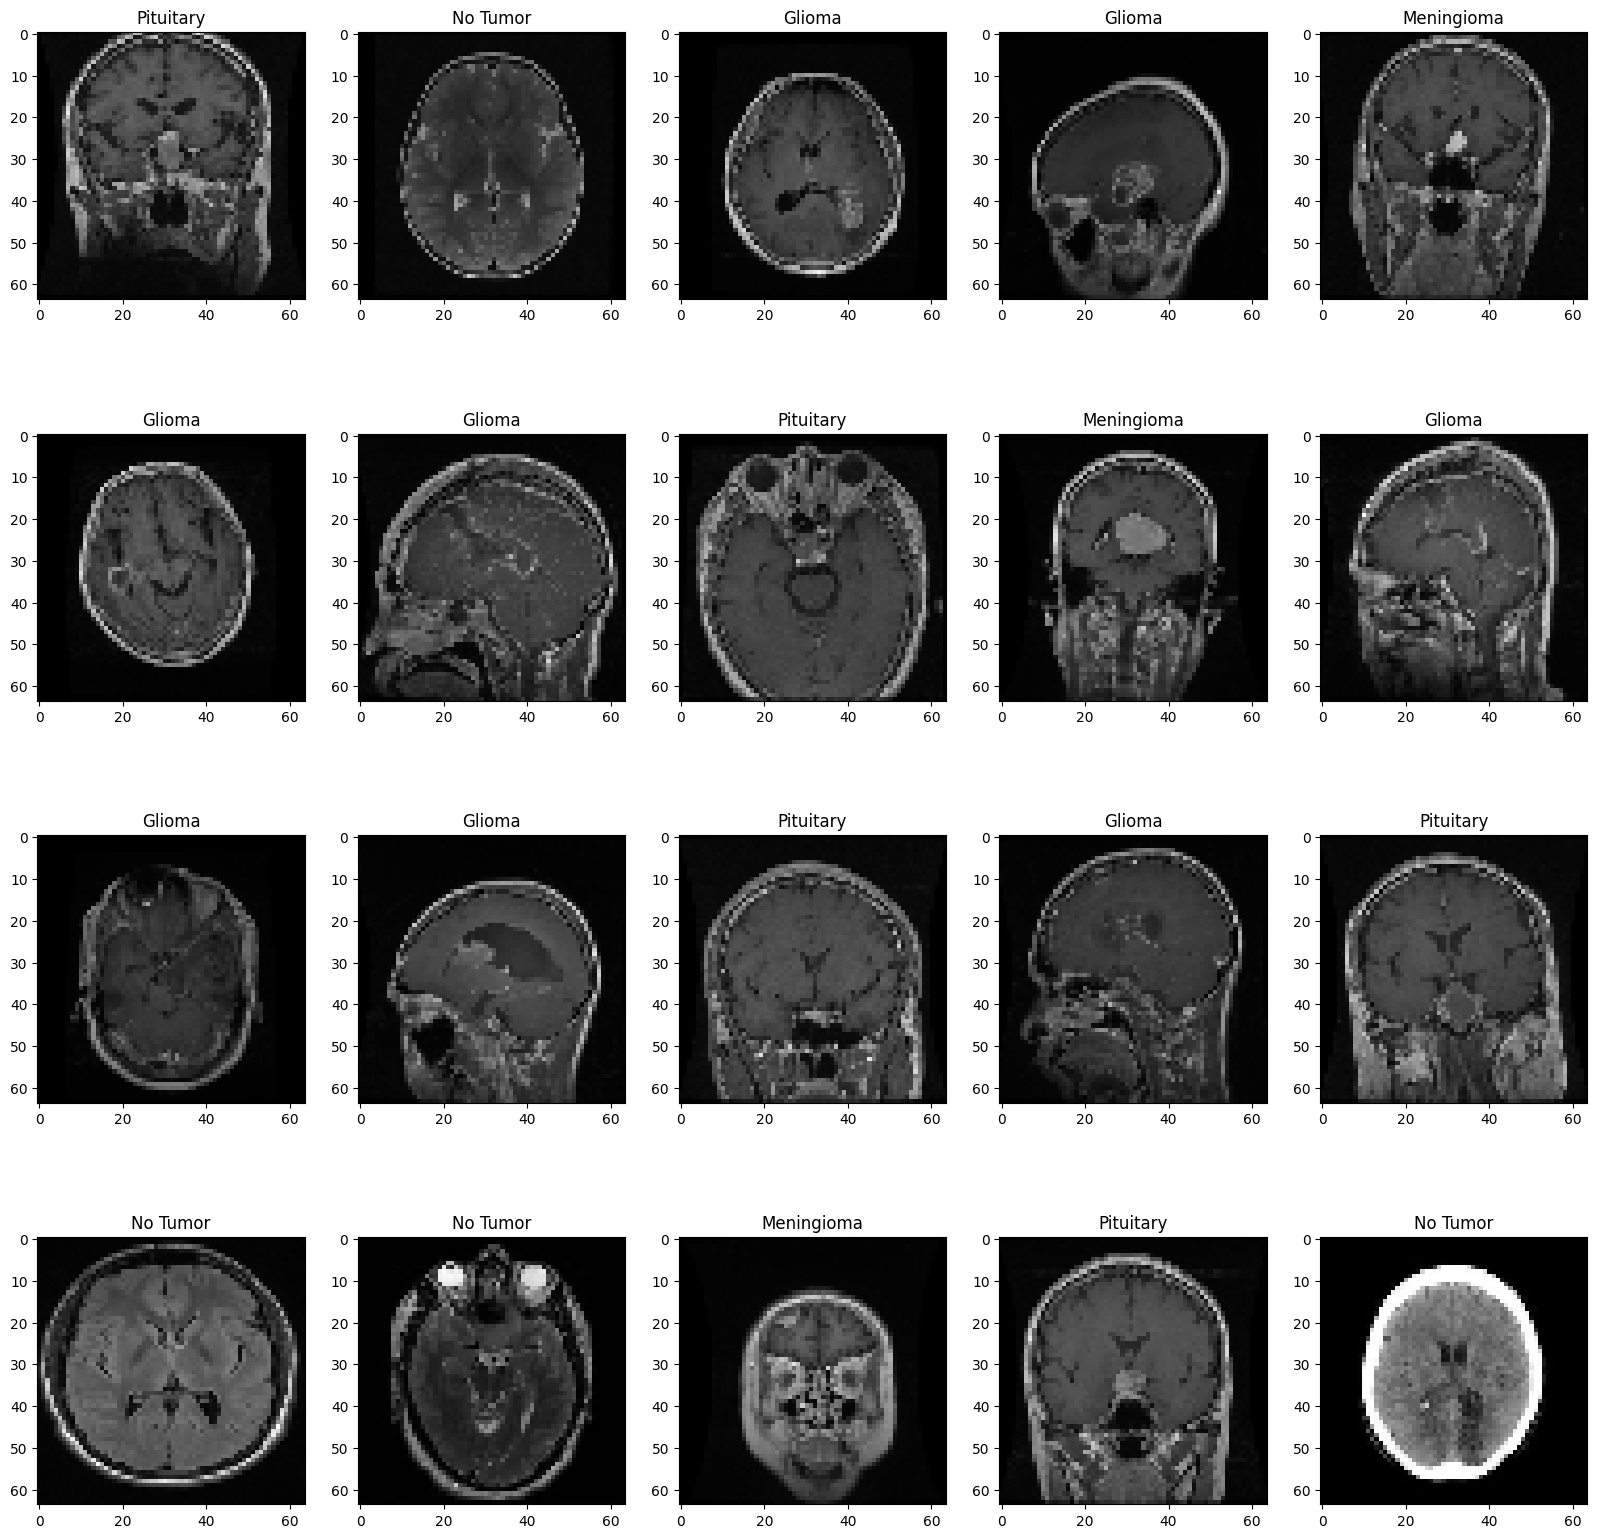

In [210]:
plt.figure(figsize=(20,20))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(X_train[i])
    if label_train[i] == 0:
        plt.title('Glioma')
    elif label_train[i] == 1:
        plt.title('Meningioma')
    elif label_train[i] == 2:
        plt.title('No Tumor')
    else:
        plt.title('Pituitary')
plt.show()

In [211]:
y_train = np.array(label_train)

In [212]:
y_test = np.array(label_test)

In [213]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(312, 64, 64, 3)
(96, 64, 64, 3)
(312,)
(96,)


In [214]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [215]:
model = keras.models.Sequential([

    keras.layers.Conv2D(32, (3,3),
                        activation='relu',
                        input_shape=(64,64,3)),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(64, (3,3),
                        activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(128, (3,3),
                        activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dropout(0.5),

    keras.layers.Dense(4, activation='softmax')

])

In [216]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']
)

In [217]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)                   │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [218]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3333 - loss: 1.3730 - val_accuracy: 0.4603 - val_loss: 1.3119
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4618 - loss: 1.2292 - val_accuracy: 0.5238 - val_loss: 1.0740
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6064 - loss: 1.0425 - val_accuracy: 0.7778 - val_loss: 0.7888
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7149 - loss: 0.7815 - val_accuracy: 0.6032 - val_loss: 0.8684
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7671 - loss: 0.6799 - val_accuracy: 0.8413 - val_loss: 0.5409


In [219]:
print(len(X_train))
print(len(y_train))
print(len(label_train))

312
312
312


In [220]:
model.evaluate(X_train,y_train)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8462 - loss: 0.4835


[0.4834749400615692, 0.8461538553237915]

In [221]:
prediction = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [222]:
prediction[:5]

array([[5.0936264e-01, 2.1020173e-01, 2.6350760e-01, 1.6928041e-02],
       [2.3756715e-02, 9.6350368e-03, 1.6891812e-01, 7.9769015e-01],
       [8.3463006e-03, 6.2670903e-03, 2.8993446e-01, 6.9545215e-01],
       [2.1040870e-03, 6.5172330e-04, 1.8578838e-01, 8.1145585e-01],
       [9.2932489e-03, 8.3291098e-02, 8.5809928e-01, 4.9316362e-02]],
      dtype=float32)

In [223]:
y_pred = [np.argmax(p) for p in prediction]


In [224]:
y_pred[:5]

[np.int64(0), np.int64(3), np.int64(3), np.int64(3), np.int64(2)]

In [225]:
prediction = model.predict(X_test)

y_pred = [np.argmax(p) for p in prediction]

print(y_pred[:10])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[np.int64(0), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(3), np.int64(2)]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


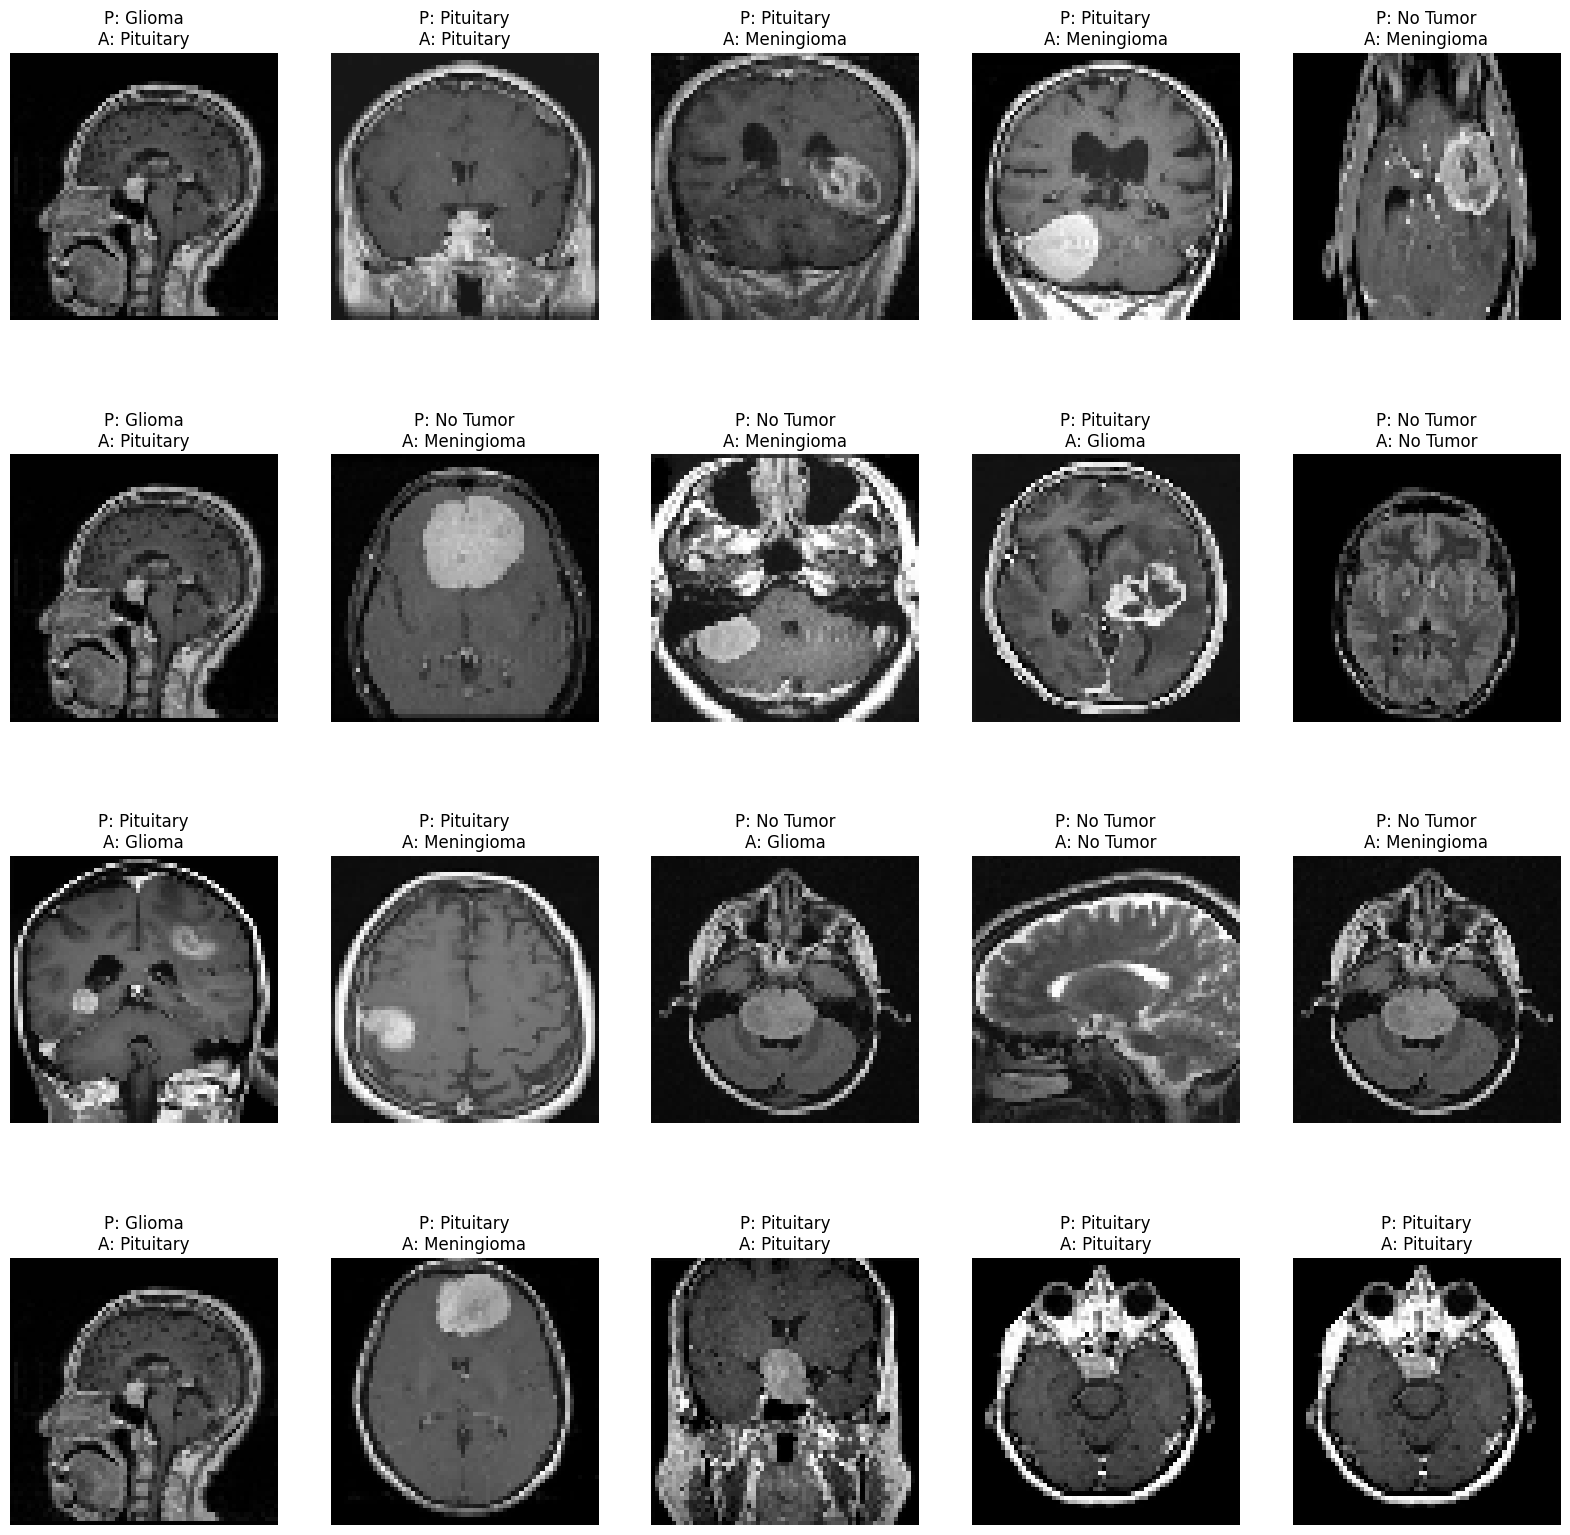

In [226]:
classes = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

prediction = model.predict(X_test)

y_pred = [np.argmax(p) for p in prediction]

plt.figure(figsize=(20,20))

for i in range(20):

    plt.subplot(4,5,i+1)

    plt.imshow(X_test[i])

    plt.title(f"P: {classes[y_pred[i]]}\nA: {classes[y_test[i]]}")

    plt.axis('off')

plt.show()

In [227]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 1  0 10 13]
 [ 1  1  8 14]
 [ 2  0 17  5]
 [ 4  0  5 15]]


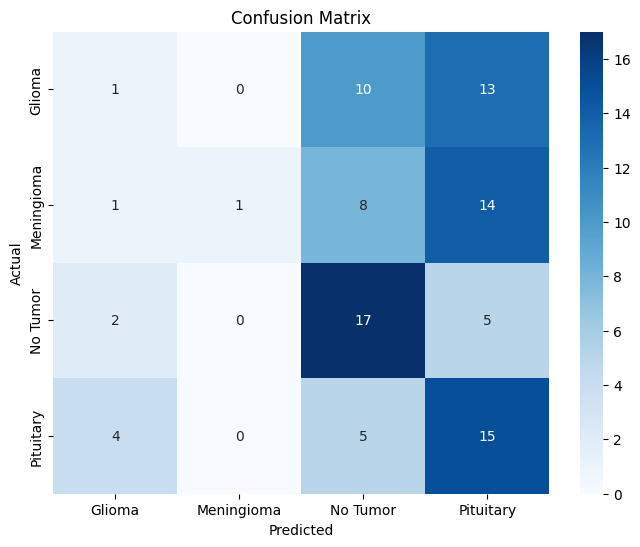

In [228]:
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Glioma','Meningioma','No Tumor','Pituitary'],
            yticklabels=['Glioma','Meningioma','No Tumor','Pituitary'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [175]:
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2, 3]), array([84, 72, 72, 84]))
